## **Dataset**

**Acoustic Measurement for Multilayer Ceramic Capacitor Damage Detection**

This dataset contains acoustic measurement data from 180 Multilayer Ceramic Capacitors (MLCCs) of the 2220 case size, 22 µF, and 24V specifications. Measurements were taken using a piezoelectric sensor during a voltage frequency sweep from 100 Hz to 2 MHz for 100 ms. Each MLCC's acoustic signature is represented by an eight-dimensional feature vector, comprising:

*   Maximum resonance amplitude
*   Frequency of the highest resonance peak
*   Amplitude of the second-highest resonance peak
*   Frequency of the second-highest resonance peak
*   Total phase shift during the frequency sweep
*   Median amplitude of the top 10 resonance peaks
*   Median frequency of the top 10 resonance peaks
*   Mean group delay ripple

The dataset also includes labels indicating the condition of each MLCC (0 = no damage; 1 = damage) based on visual inspection of cross-sectioned samples. To enhance the detection of damage, KNN classification is applied, addressing the complexities involved in the reliable detection of damage from acoustic signal analysis.

https://ieee-dataport.org/open-access/mlcc-acoustic-data-2220-case-size-processed

https://doi.org/10.1109/ACCESS.2020.3045830

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import copy

### **Load Dataset**

In [2]:
df = pd.read_csv("MLCC.csv")
df.head()

,MaxResAmp,MaxResFreq,SecMaxResAmp,SecMaxResFreq,TotalPhaseShift,Med10ResAmp,Med10ResFreq,MeanGDR,Damage
0,0.019718,0.008762,1911,1411,402000.0,0.008522,3759.5,0.090715,1
1,0.025403,0.006233,2508,1417,494000.0,0.005904,4639.0,0.137310,1
2,0.027239,0.004029,2544,1238,409000.0,0.007320,2716.0,0.086917,1
3,0.024200,0.014557,2069,1336,418000.0,0.014241,2309.5,0.097226,1
4,0.033022,0.016232,2540,1300,492000.0,0.014364,3268.5,0.133480,0


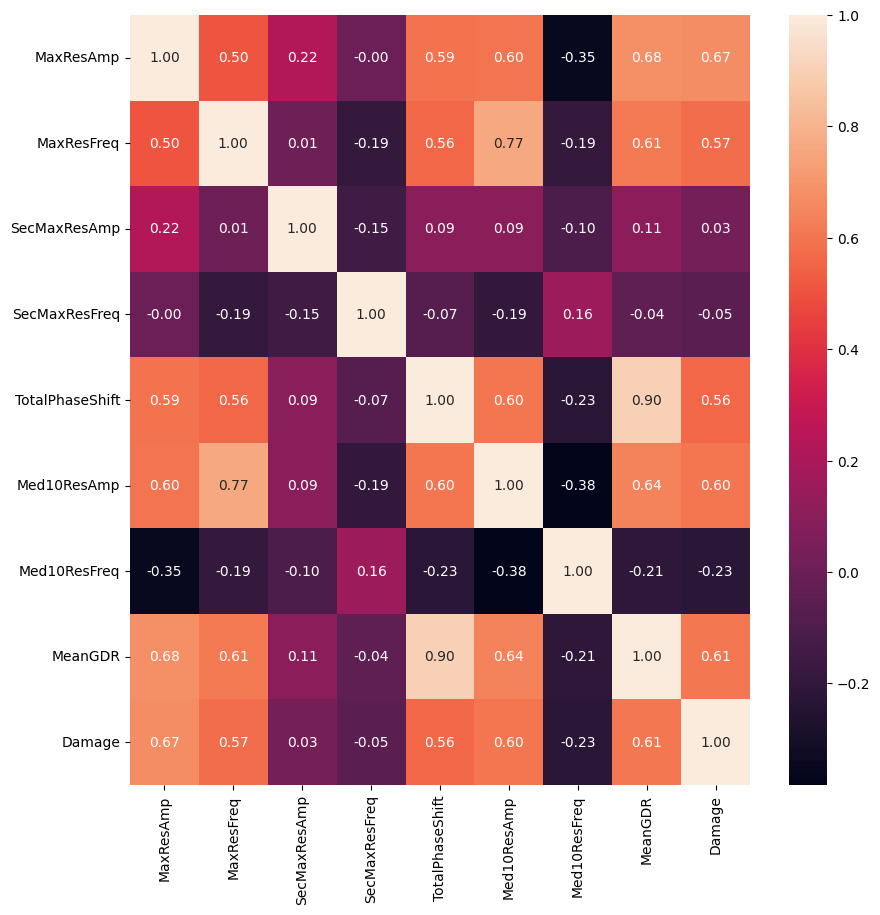

In [3]:
def plot_correlation(data):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    plt.figure(figsize=(10, 10))
    sns.heatmap(data.corr(), annot=True, fmt=".2f")
    plt.show()

data  = pd.read_csv('MLCC.csv')
plot_correlation(data)

### **Spliting Dataset into Training and Testing**

In [4]:
def train_test_split(X, y, random_state=42, test_size=0.2):
    """
    Splits the data into training and testing sets.

    Parameters:
        X (numpy.ndarray): Features array of shape (n_samples, n_features).
        y (numpy.ndarray): Target array of shape (n_samples,).
        random_state (int): Seed for the random number generator. Default is 42.
        test_size (float): Proportion of samples to include in the test set. Default is 0.2.

    Returns:
        Tuple[numpy.ndarray]: A tuple containing X_train, X_test, y_train, y_test.
    """
    # Shuffle the indices
    n_samples = X.shape[0]
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(np.arange(n_samples))

    # Split into test and train
    test_size = int(n_samples * test_size)
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [5]:
def scale_test_train_dataset(X_train, X_test):
    """
    Scales the input data using standardization.

    Parameters:
        X (numpy.ndarray): Input data to be scaled.

    Returns:
        numpy.ndarray: Scaled data.
    """
    train_mean = np.mean(X_train, axis=0)
    train_std = np.std(X_train, axis=0)
    eps = 1e-8
    X_train_scaled = (X_train-train_mean)/(train_std+eps)
    X_test_scaled = (X_test-train_mean)/(train_std+eps)
    return X_train_scaled, X_test_scaled

In [6]:
# Features and Label
X = df.drop(columns='Damage').values
y = df['Damage'].values               

# Split the  data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Feature scaling (standardization)
X_train, X_test = scale_test_train_dataset(X_train, X_test)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (144, 8) (144,)
Testing set shape: (36, 8) (36,)


## **Logistic Regression**

### **Train Log Regression Model**

In [7]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z

    """

    g = 1/(1+np.exp(-z))

    return g

In [8]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost

    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters
      b (scalar)       : model parameter

    Returns:
      cost (scalar): cost
    """

    N = X.shape[0]
    cost = 0.0
    for i in range(N):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

    cost = cost / N
    return cost

In [9]:
def compute_gradient_logistic(X, y, w, b):
    """
    Computes the gradient for logistic regression

    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters
      b (scalar)      : model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w.
      dj_db (scalar)      : The gradient of the cost w.r.t. the parameter b.
    """
    dj_dw = np.zeros_like(X[0])                       # (F,)
    dj_db = 0.

    for i in range(X.shape[0]):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          # (F,).(F,) = (1,)
        err_i  = f_wb_i  - y[i]                       # (1, )
        for j in range(X.shape[1]):
           dj_dw[j] = dj_dw[j] + err_i * X[i,j]       # (1,)
        # dj_dw += err_i * X[i]                       # (F,)
        dj_db += err_i

    dj_dw = dj_dw/X.shape[0]                          # (F,)
    dj_db = dj_db/X.shape[0]                          # (1,)

    # Vectorized version
    # f_wb = sigmoid(X @ w + b)                         # (N,)
    # dj_dw = (X.T @ (f_wb - y)) / X.shape[0]           # (N, F).T @ (N) = (F,)
    # dj_db = np.sum(f_wb - y) / X.shape[0]             # (1,)

    return dj_db, dj_dw

In [10]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """
    Performs batch gradient descent

    Args:
      X (ndarray (m,n)   : Data, m examples with n features
      y (ndarray (m,))   : target values
      w_in (ndarray (n,)): Initial values of model parameters
      b_in (scalar)      : Initial values of model parameter
      alpha (float)      : Learning rate
      num_iters (scalar) : number of iterations to run gradient descent

    Returns:
      w (ndarray (n,))   : Updated values of parameters
      b (scalar)         : Updated value of parameter
    """
    
    J_history = []
    w_history = []
    b_history = []
    
    w = copy.deepcopy(w_in) 
    b = copy.deepcopy(b_in)

    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i<100000:                # prevent resource exhaustion
            J_history.append(compute_cost_logistic(X, y, w, b))
            w_history.append(w)
            b_history.append(b)
        print(f"Iteration {i+1:4d}: Cost {J_history[-1]} w={w_history[-1]} b={b_history[-1]}")

    return w, b, J_history


In [11]:
# Train parameters
alph = 0.1
iters = 10000

# Initialize weight and bias
w_tmp  = np.zeros_like(X_train[0])              # (F,)
b_tmp  = 0.1                                    # (1,)

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    1: Cost 0.6848431885284592 w=[ 0.02633108  0.02417545 -0.00059581 -0.00079097  0.0226641   0.02419452
 -0.00877253  0.02437918] b=0.06764097014099482
Iteration    2: Cost 0.6510584441837739 w=[ 0.05050512  0.04619762 -0.00147822 -0.00131385  0.04307203  0.0461015
 -0.01652511  0.04636826] b=0.0360973606371758
Iteration    3: Cost 0.621885000468076 w=[ 0.0727676   0.06631332 -0.00260933 -0.00159813  0.06147127  0.06597283
 -0.02337181  0.06623324] b=0.005364162267927984
Iteration    4: Cost 0.5964826819005573 w=[ 0.09335228  0.08475725 -0.00395382 -0.00167149  0.07809691  0.08404671
 -0.02942098  0.08422732] b=-0.024568026651627686
Iteration    5: Cost 0.5741761447965621 w=[ 0.11246893  0.10173954 -0.00547998 -0.00155996  0.09316151  0.10053743
 -0.03477079  0.10057886] b=-0.05371389588825132
Iteration    6: Cost 0.5544284614694235 w=[ 0.13029975  0.11744212 -0.00715987 -0.00128767  0.10685198  0.1156327
 -0.03950778  0.11548782] b=-0.08209283076260726
Iteration    7: Cost 

### **Generate Predictions**

In [12]:
def predict(X, weights, bias):
    # logits = np.dot(X, weights) + bias
    logits = X @ weights + bias
    y_pred = sigmoid(logits)
    return [1 if i > 0.5 else 0 for i in y_pred]

In [13]:
# Predict on the training set with scaled features
y_pred_logistic = predict(X_test, w_out, b_out)
print(y_pred_logistic)

[0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


## **KNN Model**

K-Nearest Neighbors (KNN) is an intuitive, non-parametric machine learning algorithm primarily used for classification. KNN classifies data points based on their proximity to each other in feature space. Given a new data point, the algorithm finds the $K$ closest points in the training set and assigns the most common label among them as the prediction. The choice of distance metric and the value of $K$ play crucial roles in KNN's performance.

**Mathematical Model for KNN**

**Problem Setting**

Given:

We have a training dataset containing $n$ labeled training samples:

$$
DF = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}
$$

where:

- $x_i \in \mathbb{R}^d$ represents the feature vector of the $i$-th training sample.
- $y_i$ represents the class label associated with the $i$-th training sample.
- $i = 1, 2, \dots, n$ identifies each training sample.
- $d$ is the number of features in each sample.

For example, the $i$-th feature vector can be written as:

$$
x_i = (x_{i,1}, x_{i,2}, \dots, x_{i,d})
$$

where $x_{i,j}$ represents the value of the $j$-th feature of the $i$-th training sample.

We are also given a new data point, called the **query point**, whose class label is unknown:

$$
x = (x_1, x_2, \dots, x_d)
$$

The goal of KNN is to use the labeled training samples to predict the class of this query point:

$$
y_{\text{pred}}
$$


**Steps**

1. **Distance Metric**

   The first step is to measure the distance between the query point $x$ and each training point $x_i$. The distance metric determines how close the query point is to each training sample.

   * **Euclidean Distance ($p=2$)**

     Euclidean distance measures the straight-line distance between two points. It is commonly used for numerical features.

     $$
     d(x, x_i)
     =
     \|x - x_i\|_2
     =
     \sqrt{
     \sum_{j=1}^{d}
     (x_j - x_{i,j})^2
     }
     $$

   * **Manhattan Distance ($p=1$)**

     Manhattan distance measures the sum of the absolute differences between corresponding features. It is also known as taxicab distance or city-block distance.

     $$
     d(x, x_i)
     =
     \|x - x_i\|_1
     =
     \sum_{j=1}^{d}
     |x_j - x_{i,j}|
     $$

   * **Minkowski Distance**

     Minkowski distance is a generalized form of the Euclidean and Manhattan distance metrics. The parameter $p$ determines the type of distance being used.

     $$
     d(x, x_i)
     =
     \left(
     \sum_{j=1}^{d}
     |x_j - x_{i,j}|^p
     \right)^{\frac{1}{p}},
     \quad p \geq 1
     $$

     For specific values of $p$:

     $$
     p=1
     \quad \Rightarrow \quad
     \text{Manhattan Distance}
     $$

     $$
     p=2
     \quad \Rightarrow \quad
     \text{Euclidean Distance}
     $$


2. **Find $K$ Nearest Neighbors**

   Compute the distance between the query point $x$ and every training point $x_i$:

   $$
   d_i = d(x, x_i),
   \quad i = 1, 2, \ldots, n
   $$

   If the dataset contains 144 training samples, then the distances are:

   $$
   d_i = d(x, x_i),
   \quad i = 1, 2, \ldots, 144
   $$

   Sort the distances in ascending order and select the $K$ training samples with the smallest distances.

   Denote the set of indices of the $K$ nearest neighbors by:

   $$
   \mathcal{N}_K(x)
   $$

   For example, if $K=3$ and the three closest training samples are samples 7, 12, and 25, then:

   $$
   \mathcal{N}_3(x) = \{7, 12, 25\}
   $$

   The choice of $K$ is important:

   - A small $K$ makes the model more sensitive to noise and individual observations, which can lead to overfitting.
   - A large $K$ considers more training samples and produces smoother predictions, but it can lead to underfitting.
   - For binary classification, an odd value of $K$ is often preferred to reduce the possibility of tied votes.
   - Generally, $K$ should be large enough to provide a meaningful vote while remaining small enough to preserve local patterns in the data.


3. **Prediction**

   Once the $K$ nearest neighbors have been identified, KNN predicts the class based on the majority vote among their class labels.

   Let $\mathcal{C}$ represent the set of possible class labels.

   The predicted class is:

   $$
   y_{\text{pred}}
   =
   \arg\max_{c \in \mathcal{C}}
   \sum_{i \in \mathcal{N}_K(x)}
   \delta(y_i, c)
   $$

   where:

   - $\mathcal{C}$ is the set of possible class labels.
   - $\mathcal{N}_K(x)$ is the set of indices of the $K$ nearest training samples.
   - $y_i$ is the known class label of training sample $i$.
   - $\delta(y_i,c)$ is the Kronecker delta function.

   The Kronecker delta function is defined as:

   $$
   \delta(y_i,c)
   =
   \begin{cases}
   1, & \text{if } y_i = c, \\
   0, & \text{if } y_i \neq c.
   \end{cases}
   $$

   The summation therefore counts how many of the $K$ nearest neighbors belong to each class. KNN then predicts the class with the highest number of votes.


**Optimization for KNN**

Optimizing KNN involves selecting suitable values for $K$ and the distance metric. Other preprocessing choices, such as feature scaling, can also affect the performance of KNN.

1. **Choosing the Right $K$**

   A common approach is to use validation or cross-validation to evaluate different values of $K$. A $K$ that is too small can lead to noisy and less accurate predictions, while a $K$ that is too large can smooth out local patterns and reduce accuracy.

   The optimal value of $K$ can be expressed as:

   $$
   K_{\text{optimal}}
   =
   \arg\max_K
   \text{Accuracy}_{\text{validation}}(K)
   $$

   This means that we select the value of $K$ that produces the highest validation accuracy.


2. **Distance Metric Selection**

   KNN's performance also depends on the distance metric used. Different distance metrics may be more suitable depending on the characteristics and scale of the data.

   When using the Minkowski distance, the parameter $p$ can be tuned to select an appropriate distance metric.

   The optimal value of $p$ can be expressed as:

   $$
   p_{\text{optimal}}
   =
   \arg\max_p
   \text{Accuracy}_{\text{validation}}(p)
   $$

   In practice, $K$, the distance metric, and preprocessing choices such as feature scaling can be evaluated together using cross-validation.

### **Calculate the Distance**

Minkowski Distance Function


$$d(x, x_i) = \left( \sum_{j=1}^{d} |x_j - x_{i,j}|^p \right)^{\frac{1}{p}}, \quad \text{where } p \geq 1.$$

In [14]:
def distance_Minkowski(x_train, x_test_point, p):
        """
        Calculates the Minkowski distance between training points and a test point.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        x_test_point : numpy array
            The test point.
        p : int
            The power for the Minkowski distance.

        Returns:
        --------
        numpy array
            The distances from the test point to each training point.
        """
        distances = []
        for i in range(len(x_train)):
          current_train_point = x_train[i]
          current_distance = 0
          for j in range(len(current_train_point)):
            current_distance += np.abs(current_train_point[j] - x_test_point[j]) ** p
          current_distance = current_distance**(1/p)
          distances.append(current_distance)

        return np.array(distances)

Euclidean Distance Function

Here is the formula and code for calculating Euclidean distance:

$$d(x, x_i) = \|x - x_i\|_2 = \sqrt{\sum_{j=1}^{d} (x_j - x_{i,j})^2}$$


In [15]:
def distance_Euclidean(x_train, x_test_point):
        """
        Calculates the Euclidean distance between training points and a test point.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        x_test_point : numpy array
            The test point.

        Returns:
        --------
        numpy array
            The distances from the test point to each training point.
        """
        distances = []
        for i in range(len(x_train)):
          current_train_point = x_train[i]
          current_distance = 0
          for j in range(len(current_train_point)):
            current_distance += (current_train_point[j] - x_test_point[j]) ** 2
          current_distance = np.sqrt(current_distance)
          distances.append(current_distance)

        return np.array(distances)

Manhattan Distance Function

Here is the formula and code for calculating Manhattan distance:

$$d(x, x_i) = \|x - x_i\|_1 = \sum_{j=1}^{d} |x_j - x_{i,j}|
$$

In [16]:
def distance_Manhattan(x_train, x_test_point):
        """
        Calculates the Manhattan distance between training points and a test point.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        x_test_point : numpy array
            The test point.

        Returns:
        --------
        numpy array
            The distances from the test point to each training point.
        """
        distances = []
        for i in range(len(x_train)):
          current_train_point = x_train[i]
          current_distance = 0
          for j in range(len(current_train_point)):
            current_distance += np.abs(current_train_point[j] - x_test_point[j])
          distances.append(current_distance)

        return np.array(distances)

### **Find the Nearest Neighbors**

In [17]:
def nearest_neighbors(distance_point, K):
        """
        Finds the indices of the K nearest neighbors.

        Parameters:
        -----------
        distance_point : numpy array
            The distances from the test point to each training point.
        K : int
            The number of neighbors to consider.

        Returns:
        --------
        numpy array
            The indices of the K nearest neighbors.
        """
        # Sort the distances and get the indices that would sort the array
        sorted_indices = np.argsort(distance_point)

        # Take only the first K neighbors
        nearest_indices = sorted_indices[:K]
        return nearest_indices

### **Classify the Point Based on the Majority Vote**

In [18]:
def voting(nearest_indices, y_train):
        """
        Determines the majority label among the nearest neighbors.

        Parameters:
        -----------
        nearest_indices : numpy array
            The indices of the nearest neighbors.

        Returns:
        --------
        int
            The predicted class label.
        """
        # Initialize counters for labels 0 and 1
        count_0 = 0
        count_1 = 0

        # Iterate through the indices of the nearest neighbors
        for index in nearest_indices:
            if y_train[index] == 0:
                count_0 += 1
            elif y_train[index] == 1:
                count_1 += 1

        # Determine the majority label
        if count_1 > count_0:
            majority_label = 1
        else:
            majority_label = 0

        return majority_label

### **Generating Predictions**

#### **KNN with Minkowski Distance**

In [19]:
def KNN_Minkowski(X_train, y_train, x_test, K, p):
        """
        Predicts the class labels for the input data.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        y_train : numpy array
            The training labels.
        x_test : numpy array
            The test features.
        K : int
            The number of neighbors to consider.
        p : int
            The power for the Minkowski distance.

        Returns:
        --------
        numpy array
            The predicted class labels.
        """
        y_pred = []

        for x_test_point in x_test:
            distance_point = distance_Minkowski(X_train, x_test_point, p)
            nearest_indices = nearest_neighbors(distance_point, K)
            y_pred_point = voting(nearest_indices, y_train)
            y_pred.append(y_pred_point)

        return np.array(y_pred)

In [22]:
def plot_knn_minkowski(X_train, y_train, K=10, p=3):
    # Use only the first two features for plotting
    X_train_2d = X_train[:, [0, 7]]                                         # Select columns 1 and 8 (index 0 and 7)

    # Define the min and max for x and y axis with a margin
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

    # Generate a mesh grid for plotting
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predictions for each point in the grid
    Z = []
    for x_test_point in np.c_[xx.ravel(), yy.ravel()]:
        # Pass X_train_2d to distance_Minkowski to use only 2 features
        distances = distance_Minkowski(x_train=X_train_2d, x_test_point=x_test_point, p=p)
        nearest_indices = nearest_neighbors(distances, K)
        Z.append(voting(nearest_indices, y_train))

    Z = np.array(Z).reshape(xx.shape)

    # Color maps for the background and data points
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    # Plot decision boundaries
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Scatter plot for training points, using only 2 features
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=50)
    plt.title(f"KNN Decision Boundary (Minkowski Distance, K={K}, p={p})")
    plt.xlabel("MaxResAmp")
    plt.ylabel("MeanGDR")
    plt.show()

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


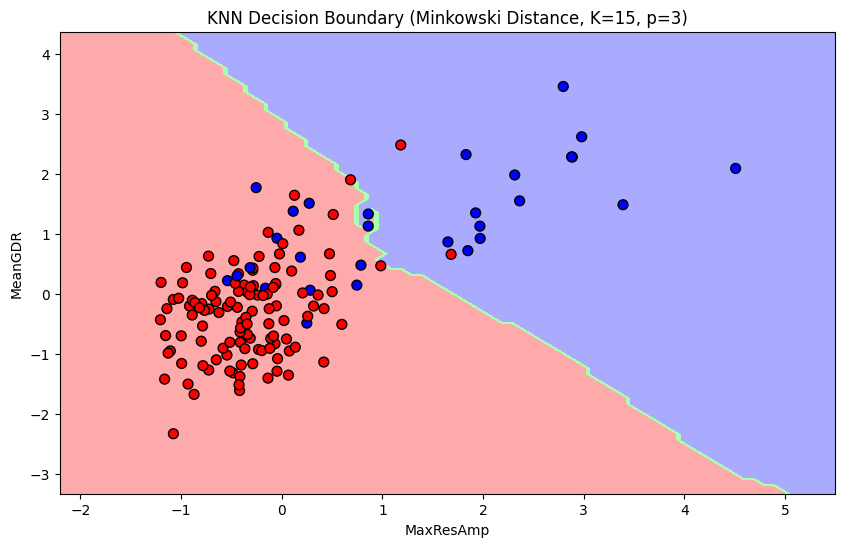

In [23]:
K = 15
p = 3

y_pred_knn_minkowski = KNN_Minkowski(X_train, y_train, X_test, K, p)  # Predict using KNN with Minkowski distance
print(y_pred_knn_minkowski)
plot_knn_minkowski(X_train, y_train, K, p)

#### **KNN with Euclidean Distance**

In [24]:
def KNN_Euclidean(x_train, y_train, x_test, K):
        """
        Predicts the class labels for the input data.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        y_train : numpy array
            The training labels.
        x_test : numpy array
            The test features.
        K : int
            The number of neighbors to consider.

        Returns:
        --------
        numpy array
            The predicted class labels.
        """
        y_pred = []
        
        for x_test_point in x_test:
            distance_point = distance_Euclidean(x_train, x_test_point)
            nearest_indices = nearest_neighbors(distance_point, K)
            y_pred_point = voting(nearest_indices, y_train)
            y_pred.append(y_pred_point)

        return np.array(y_pred)

In [25]:
def plot_knn_euclidean(X_train, y_train, K=10):
    # Use only the first two features for plotting
    X_train_2d = X_train[:, [0, 7]]                                             # Select columns 1 and 8 (index 0 and 7)

    # Define the min and max for x and y axis with a margin
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

    # Generate a mesh grid for plotting
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predictions for each point in the grid
    Z = []
    for x_test_point in np.c_[xx.ravel(), yy.ravel()]:
        # Pass X_train_2d to distance_Minkowski to use only 2 features
        distances = distance_Euclidean(x_train=X_train_2d, x_test_point=x_test_point)
        nearest_indices = nearest_neighbors(distances, K)
        Z.append(voting(nearest_indices, y_train))

    Z = np.array(Z).reshape(xx.shape)

    # Color maps for the background and data points
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    # Plot decision boundaries
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Scatter plot for training points, using only 2 features
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=50)
    plt.title(f"KNN Decision Boundary (Euclidean Distance, K={K})")
    plt.xlabel("MaxResAmp")
    plt.ylabel("MeanGDR")
    plt.show()

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


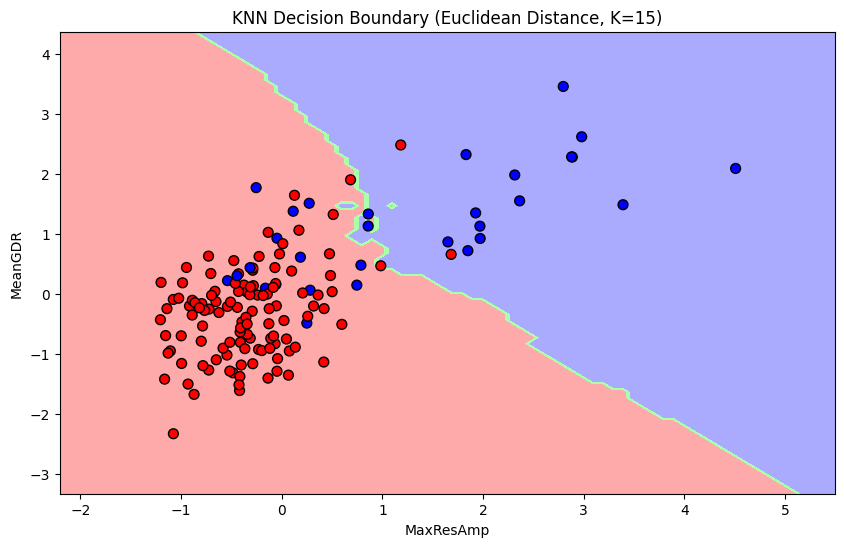

In [26]:
K = 15
y_pred_knn_euclidean = KNN_Euclidean(X_train, y_train, X_test, K)  
print(y_pred_knn_euclidean)
plot_knn_euclidean(X_train, y_train, K)

#### **KNN with Manhattan Distance**

In [27]:
def KNN_Manhattan(x_train, y_train, x_test, K):
        """
        Predicts the class labels for the input data.

        Parameters:
        -----------
        x_train : numpy array
            The training features.
        y_train : numpy array
            The training labels.
        x_test : numpy array
            The test features.
        K : int
            The number of neighbors to consider.

        Returns:
        --------
        numpy array
            The predicted class labels.
        """
        y_pred = []

        for x_test_point in x_test:
            distance_point = distance_Manhattan(x_train, x_test_point)
            nearest_indices = nearest_neighbors(distance_point, K)
            y_pred_point = voting(nearest_indices, y_train)
            y_pred.append(y_pred_point)

        return np.array(y_pred)

In [28]:
def plot_knn_manhattan(X_train, y_train, K=10):
    # Use only the first two features for plotting
    X_train_2d = X_train[:, [0, 7]]  # Select columns 1 and 8 (index 0 and 7)

    # Define the min and max for x and y axis with a margin
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

    # Generate a mesh grid for plotting
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predictions for each point in the grid
    Z = []
    for x_test_point in np.c_[xx.ravel(), yy.ravel()]:
        # Pass X_train_2d to distance_Minkowski to use only 2 features
        distances = distance_Manhattan(x_train=X_train_2d, x_test_point=x_test_point)
        nearest_indices = nearest_neighbors(distances, K)
        Z.append(voting(nearest_indices, y_train))

    Z = np.array(Z).reshape(xx.shape)

    # Color maps for the background and data points
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    # Plot decision boundaries
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Scatter plot for training points, using only 2 features
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=50)
    plt.title(f"KNN Decision Boundary (Manhattan Distance, K={K})")
    plt.xlabel("MaxResAmp")
    plt.ylabel("MeanGDR")
    plt.show()

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


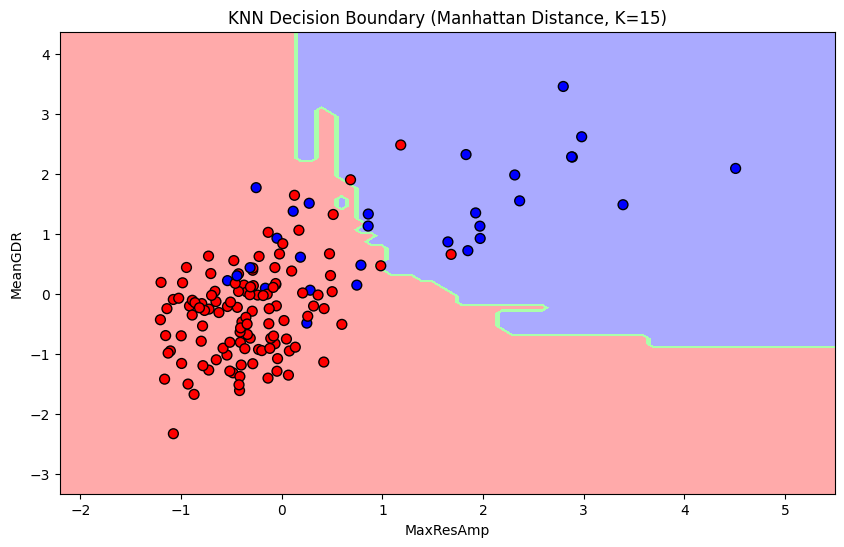

In [29]:
K = 15
y_pred_knn_manhattan = KNN_Manhattan(X_train, y_train, X_test, K)  # Predict using KNN with Manhattan distance
print(y_pred_knn_manhattan)
plot_knn_manhattan(X_train, y_train, K)

## **Evaluation**
Confusion matrix contains four values: True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). These values help assess the model's performance and can be used to calculate metrics like accuracy, error rate, precision, recall, specificity, and F1Score.
<br>
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{ \text{P} + \text{N}}$$
<br>
$$\text{Error Rate} = \frac{\text{FP} + \text{FN}}{ \text{P} + \text{N}}$$
<br>
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
<br>
$$\text{Recall} = \frac{\text{TP}}{\text{P}}$$
<br>
$$\text{Specificity} = \frac{\text{TN}}{\text{N}}$$
<br>
$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$




In [30]:
def confusion_matrix(y_true, y_pred):
    """
      Computes the confusion matrix for binary classification.

      Args:
        y_true (list or array-like): Actual labels (ground truth) for the dataset.
          Should contain binary values (0 and 1).
        y_pred (list or array-like): Predicted labels from the model.
          Should also contain binary values (0 and 1).

      Returns:
        list: A 2x2 confusion matrix as a list of lists in the format:
          [[TP, FP],
          [FN, TN]]
          where:
            - TP: True Positives (actual 1, predicted 1)
            - FP: False Positives (actual 0, predicted 1)
            - TN: True Negatives (actual 0, predicted 0)
            - FN: False Negatives (actual 1, predicted 0)
      """
    # Initialize counts
    TP = FP = TN = FN = 0

    # Calculate TP, FP, TN, FN
    for actual, predicted in zip(y_true, y_pred):
        if actual == 1 and predicted == 1:
            TP += 1
        elif actual == 0 and predicted == 1:
            FP += 1
        elif actual == 0 and predicted == 0:
            TN += 1
        elif actual == 1 and predicted == 0:
            FN += 1

    # Create confusion matrix
    matrix = [[TP, FP], [FN, TN]]
    return matrix

In [31]:
# Count the occurrences of 0 and 1
y_true = y_test
count_1 = np.sum(y_true == 1)
count_0 = np.sum(y_true == 0)

print(f"Number of 0s in y_true: {count_0}")
print(f"Number of 1s in y_true: {count_1}")

Number of 0s in y_true: 28
Number of 1s in y_true: 8


In [32]:
# Logistic Regression
conf_matrix_logistic = confusion_matrix(y_true, y_pred_logistic)
print("Confusion Matrix for Logistic Regression:")
print(f"TP: {conf_matrix_logistic[0][0]}, FP: {conf_matrix_logistic[0][1]}")
print(f"FN: {conf_matrix_logistic[1][0]}, TN: {conf_matrix_logistic[1][1]}")
print(conf_matrix_logistic, "\n")

# KNN with Minkowski Distance
conf_matrix_minkowski = confusion_matrix(y_true, y_pred_knn_minkowski)
print("Confusion Matrix for KNN with Minkowski Distance:")
print(f"TP: {conf_matrix_minkowski[0][0]}, FP: {conf_matrix_minkowski[0][1]}")
print(f"FN: {conf_matrix_minkowski[1][0]}, TN: {conf_matrix_minkowski[1][1]}")
print(conf_matrix_minkowski, "\n")

# KNN with Euclidean Distance
conf_matrix_euclidean = confusion_matrix(y_true, y_pred_knn_euclidean)
print("Confusion Matrix KNN with Euclidean Distance:")
print(f"TP: {conf_matrix_euclidean[0][0]}, FP: {conf_matrix_euclidean[0][1]}")
print(f"FN: {conf_matrix_euclidean[1][0]}, TN: {conf_matrix_euclidean[1][1]}")
print(conf_matrix_euclidean, "\n")

# KNN with Manhattan Distance
conf_matrix_manhattan = confusion_matrix(y_true, y_pred_knn_manhattan)
print("Confusion Matrix KNN with Manhattan Distance:")
print(f"TP: {conf_matrix_manhattan[0][0]}, FP: {conf_matrix_manhattan[0][1]}")
print(f"FN: {conf_matrix_manhattan[1][0]}, TN: {conf_matrix_manhattan[1][1]}")
print(conf_matrix_manhattan, "\n")

Confusion Matrix for Logistic Regression:
TP: 7, FP: 2
FN: 1, TN: 26
[[7, 2], [1, 26]] 

Confusion Matrix for KNN with Minkowski Distance:
TP: 2, FP: 1
FN: 6, TN: 27
[[2, 1], [6, 27]] 

Confusion Matrix KNN with Euclidean Distance:
TP: 2, FP: 1
FN: 6, TN: 27
[[2, 1], [6, 27]] 

Confusion Matrix KNN with Manhattan Distance:
TP: 3, FP: 0
FN: 5, TN: 28
[[3, 0], [5, 28]] 



In [33]:
# Logistic Regression
print("Evaluation for Logistic Regression:")
print(f"Accuracy: {(conf_matrix_logistic[0][0] + conf_matrix_logistic[1][1]) / len(y_true)}")
print(f"Error rate: {(conf_matrix_logistic[0][1] + conf_matrix_logistic[1][0]) / len(y_true)}")
print(f"Precision: {conf_matrix_logistic[0][0] / (conf_matrix_logistic[0][0] + conf_matrix_logistic[0][1])}")
print(f"Recall: {conf_matrix_logistic[0][0] / count_1}")
print(f"Specificity: {conf_matrix_logistic[1][1] / count_0}")
precision = conf_matrix_logistic[0][0] / (conf_matrix_logistic[0][0] + conf_matrix_logistic[0][1])
recall = conf_matrix_logistic[0][0] / count_1
print(f"F1Score: {(2*precision*recall/(precision+recall))}")

# KNN with Minkowski Distance
print("\nEvaluation for KNN with Minkowski Distance:")
print(f"Accuracy: {(conf_matrix_minkowski[0][0] + conf_matrix_minkowski[1][1]) / len(y_true)}")
print(f"Error rate: {(conf_matrix_minkowski[0][1] + conf_matrix_minkowski[1][0]) / len(y_true)}")
print(f"Precision: {conf_matrix_minkowski[0][0] / (conf_matrix_minkowski[0][0] + conf_matrix_minkowski[0][1])}")
print(f"Recall: {conf_matrix_minkowski[0][0] / count_1}")
print(f"Specificity: {conf_matrix_minkowski[1][1] / count_0}")
precision = conf_matrix_minkowski[0][0] / (conf_matrix_minkowski[0][0] + conf_matrix_minkowski[0][1])
recall = conf_matrix_minkowski[0][0] / count_1
print(f"F1Score: {(2*precision*recall/(precision+recall))}")

# KNN with Euclidean Distance
print("\nEvaluation for KNN with Euclidean Distance:")
print(f"Accuracy: {(conf_matrix_euclidean[0][0] + conf_matrix_euclidean[1][1]) / len(y_true)}")
print(f"Error rate: {(conf_matrix_euclidean[0][1] + conf_matrix_euclidean[1][0]) / len(y_true)}")
print(f"Precision: {conf_matrix_euclidean[0][0] / (conf_matrix_euclidean[0][0] + conf_matrix_euclidean[0][1])}")
print(f"Recall: {conf_matrix_euclidean[0][0] / count_1}")
print(f"Specificity: {conf_matrix_euclidean[1][1] / count_0}")
precision = conf_matrix_euclidean[0][0] / (conf_matrix_euclidean[0][0] + conf_matrix_euclidean[0][1])
recall = conf_matrix_euclidean[0][0] / count_1
print(f"F1Score: {(2*precision*recall/(precision+recall))}")

# KNN with Manhattan Distance
print("\nEvaluation for KNN with Manhattan Distance:")
print(f"Accuracy: {(conf_matrix_manhattan[0][0] + conf_matrix_manhattan[1][1]) / len(y_true)}")
print(f"Error rate: {(conf_matrix_manhattan[0][1] + conf_matrix_manhattan[1][0]) / len(y_true)}")
print(f"Precision: {conf_matrix_manhattan[0][0] / (conf_matrix_manhattan[0][0] + conf_matrix_manhattan[0][1])}")
print(f"Recall: {conf_matrix_manhattan[0][0] / count_1}")
print(f"Specificity: {conf_matrix_manhattan[1][1] / count_0}")
precision = conf_matrix_manhattan[0][0] / (conf_matrix_manhattan[0][0] + conf_matrix_manhattan[0][1])
recall = conf_matrix_manhattan[0][0] / count_1
print(f"F1Score: {(2*precision*recall/(precision+recall))}")

Evaluation for Logistic Regression:
Accuracy: 0.9166666666666666
Error rate: 0.08333333333333333
Precision: 0.7777777777777778
Recall: 0.875
Specificity: 0.9285714285714286
F1Score: 0.823529411764706

Evaluation for KNN with Minkowski Distance:
Accuracy: 0.8055555555555556
Error rate: 0.19444444444444445
Precision: 0.6666666666666666
Recall: 0.25
Specificity: 0.9642857142857143
F1Score: 0.36363636363636365

Evaluation for KNN with Euclidean Distance:
Accuracy: 0.8055555555555556
Error rate: 0.19444444444444445
Precision: 0.6666666666666666
Recall: 0.25
Specificity: 0.9642857142857143
F1Score: 0.36363636363636365

Evaluation for KNN with Manhattan Distance:
Accuracy: 0.8611111111111112
Error rate: 0.1388888888888889
Precision: 1.0
Recall: 0.375
Specificity: 1.0
F1Score: 0.5454545454545454
